In [1]:
import os
import sys
from dotenv import find_dotenv
sys.path.append(os.path.dirname(find_dotenv()))
import glob
from pathlib import Path
import multiprocessing

from jax import config as jax_config
jax_config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import astropy.units as u
import astropy.constants as const
import arby
import tqdm
import dill as pickle
import emcee
import dynesty
import dynesty.plotting
import corner
from multiprocess.pool import Pool, ThreadPool
# from multiprocessing import ThreadPool

import dill
import dynesty.utils
dynesty.utils.pickle_module = dill

import isidora.waveform
import isidora.plotting
import isidora.training

/project2/kmpardo_1034/conda/envs/isidora/lib/python3.11/site-packages/cupyx/jit/_interface.py:247: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
/project2/kmpardo_1034/conda/envs/isidora/lib/python3.11/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


# Make exact and ROQ waveform functions

In [2]:
downsampled_time_data = np.load('data/toy-mcmc/downsampled_time.npz')
downsampled_time, downsample_mask = downsampled_time_data['downsampled_time'], downsampled_time_data['mask']

downsampled_time *= u.s

In [3]:
(downsampled_time[-1]).to(u.yr)

<Quantity 3.49965777 yr>

In [4]:
with open('data/toy-mcmc/injected_wf_params.pkl', 'rb') as f:
    injected_wf_params = pickle.load(f)

print(injected_wf_params)

wf_amp = injected_wf_params['wf_amp_factor']

{'q': 1, 'init_phi': 3.141592653589793, 'initial_freq': <Quantity 1.04290947e-06 Hz>, 'Mc': <Quantity 30000000. solMass>, 'wf_amp_factor': np.float64(0.004950309155922981)}


In [5]:
with open('data/training_set_full_tile.pkl', 'rb') as f:
    full_tile = pickle.load(f)

full_time = full_tile.physical_time
full_tile.physical_time = downsampled_time

exact_wf_func = lambda p: wf_amp * np.real(full_tile.generate_full_waveform(p))

In [6]:
PARTITIONED_ROQ_PATH = Path('data/maestro/pipeline-test-splits_20260625-160601/split-tile-compute-rbs/nfreq_overlap_2.ntiles_7.strategy_minMc_freq')

with open(PARTITIONED_ROQ_PATH / 'reconstructed_wf_dict.pkl', 'rb') as f:
    roq_wf_dict = pickle.load(f)

freq_splits = np.unique(sum([[t[0].to(u.Hz).value, t[1].to(u.Hz).value] for t in roq_wf_dict.keys()], []))
freq_splits = u.Quantity(freq_splits, unit=u.Hz)
print(freq_splits)

valid_freq_extent = (min(freq_splits), max(freq_splits))
valid_Mc_extent = (1e7 * u.Msun, 1e10 * u.Msun)

[1.00000000e-08 8.94535738e-07 1.77336479e-06 2.65219385e-06
 3.53102290e-06 4.40985196e-06 5.28868102e-06 6.17321675e-06] Hz


In [7]:
# NB: this is admittedly cutting corners, since the ROQ weights aren't explicitly computed and then used.
# This should be equivalent to within floating-point (order-of-op) precision, but see 'ROQ Likelihood Verification.ipynb' for check on this.
def roq_wf_func(params):
    for freq_lim, wf_func in roq_wf_dict.items():
        if freq_lim[0] <= params['initial_freq'] < freq_lim[1]:
            return wf_amp * np.real(wf_func(full_time, params)[downsample_mask])
    raise RuntimeException

In [8]:
with open('data/toy-mcmc/roq-wf-func.pickle', 'wb') as f:
    pickle.dump(roq_wf_func, f, recurse=True)

In [9]:
roq_wf_dict.keys()

dict_keys([(<Quantity 1.e-08 Hz>, <Quantity 8.94535738e-07 Hz>), (<Quantity 8.94535738e-07 Hz>, <Quantity 1.77336479e-06 Hz>), (<Quantity 1.77336479e-06 Hz>, <Quantity 2.65219385e-06 Hz>), (<Quantity 2.65219385e-06 Hz>, <Quantity 3.5310229e-06 Hz>), (<Quantity 3.5310229e-06 Hz>, <Quantity 4.40985196e-06 Hz>), (<Quantity 4.40985196e-06 Hz>, <Quantity 5.28868102e-06 Hz>), (<Quantity 5.28868102e-06 Hz>, <Quantity 6.17321675e-06 Hz>)])

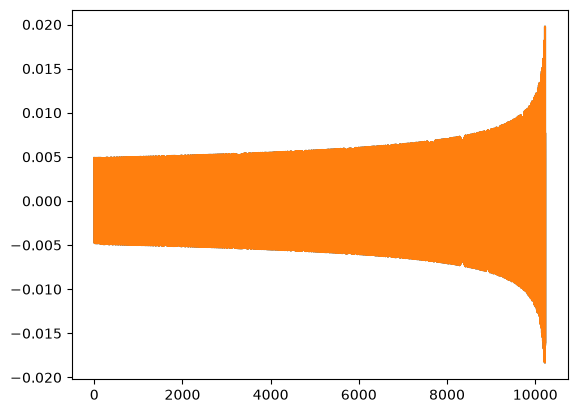

{'q': 1, 'init_phi': 0, 'initial_freq': <Quantity 6.16180339e-06 Hz>, 'Mc': <Quantity 10045848.69232559 solMass>}


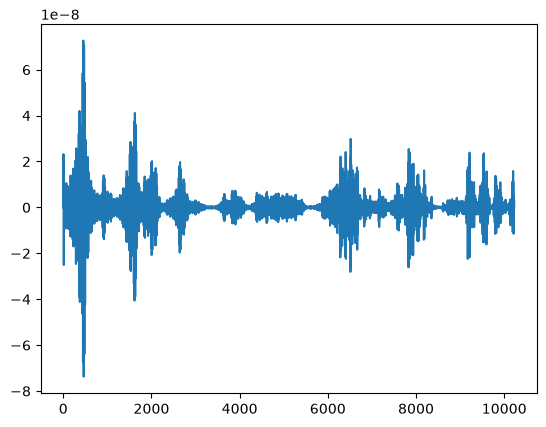

In [10]:
i = -20

plt.plot(exact_wf_func(full_tile.tile_full_gw_param_list[i]))
plt.plot(roq_wf_func(full_tile.tile_full_gw_param_list[i]))

plt.show()
plt.plot(exact_wf_func(full_tile.tile_full_gw_param_list[i]) - roq_wf_func(full_tile.tile_full_gw_param_list[i]))
print(full_tile.tile_full_gw_param_list[i])

# Set up prior and log-likelihood

In [11]:
mock_data = np.load('data/toy-mcmc/mock_data.npy')
invcov = np.load('data/toy-mcmc/inverse_covariance.npy')

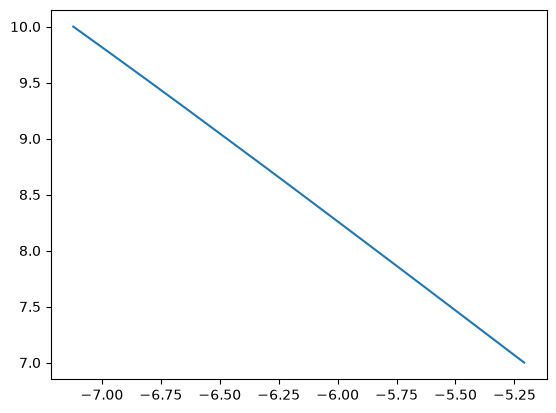

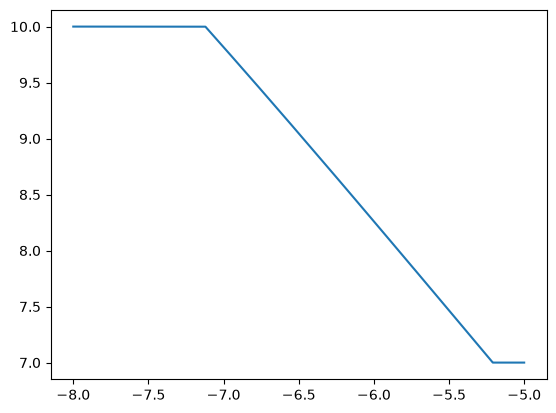

In [12]:
meco_lim_data = np.load('data/meco_limiting_Mc.npz')
valid_mask = np.isfinite(meco_lim_data['limit_Mc'])
meco_lim_data_loghz = np.log10(meco_lim_data['freq_hz'][valid_mask])
meco_lim_data_logMc = np.log10(meco_lim_data['limit_Mc'][valid_mask])

plt.plot(meco_lim_data_loghz, meco_lim_data_logMc)
plt.show()

def meco_log_Mc_lim_func(log_freq_hz):
    return np.interp(log_freq_hz, meco_lim_data_loghz, meco_lim_data_logMc)

plt.plot(np.log10(meco_lim_data['freq_hz']), meco_log_Mc_lim_func(np.log10(meco_lim_data['freq_hz'])))

In [13]:
valid_freq_extent_loghz = [np.log10(valid_freq_extent[0].to(u.Hz).value), np.log10(valid_freq_extent[1].to(u.Hz).value)]
valid_Mc_extent_logMsun = [np.log10(valid_Mc_extent[0].to(u.Msun).value), np.log10(valid_Mc_extent[1].to(u.Msun).value)]

# TODO: hacky cutoff
# valid_freq_extent_loghz[0] = -7

# Log-uniform for both freq and Mc
def prior(theta):
    log_freq_hz, log_Mc_Msun = theta
    if (not (valid_freq_extent_loghz[0] <= log_freq_hz < valid_freq_extent_loghz[1])) or (not (valid_Mc_extent_logMsun[0] <= log_Mc_Msun < meco_log_Mc_lim_func(log_freq_hz))):
        return -np.inf
    else:
        return 0

In [14]:
with open('data/toy-mcmc/prior-func.pickle', 'wb') as f:
    pickle.dump(prior, f, recurse=True)

In [15]:
invcov_slogdet = np.linalg.slogdet(invcov)
# Covariance is positive-definite -> det(C) > 0. Since det(invcov) = 1 / det(C), its sign is also positive, and log-det(invcov) = -log-det(C)
assert invcov_slogdet.sign == 1
covariance_logdet = -invcov_slogdet.logabsdet

In [15]:
@jax.jit
def jit_inner_prod(signal):
    if mock_data.ndim == 2:
        diff_vec_collection = mock_data - signal[jnp.newaxis, :]
        ip = jnp.sum(jnp.einsum('ai,ij,aj->a', diff_vec_collection, invcov, diff_vec_collection))
        # ip = 0
        # for i in range(len(mock_data)):
        #     diff_vec = mock_data[i] - signal
        #     ip += jnp.einsum('i,ij,j', diff_vec, invcov, diff_vec)
        return ip
    else:
        diff_vec = mock_data - signal
        return jnp.einsum('i,ij,j', diff_vec, invcov, diff_vec)

if mock_data.ndim == 2:
    n_stars = mock_data.shape[0]
else:
    n_stars = 1
n_obs = mock_data.shape[-1]
# Since nested sampling termination might care about this? I don't think so though.
normalization_term = n_stars * ((-n_obs / 2 * np.log(2 * np.pi)) + -0.5 * covariance_logdet)

def log_prob(theta, wf_func):
    log_freq_hz, log_Mc_Msun = theta
    wf_params = {
        'initial_freq': 10**log_freq_hz * u.Hz,
        'Mc': 10**log_Mc_Msun * u.Msun,
        # These are fixed to true.
        'init_phi': injected_wf_params['init_phi'],
        'q': injected_wf_params['q'],
    }

    if prior(theta) == 0:
        #diff_vec = mock_data - wf_func(wf_params)
        #return -0.5 * np.einsum('i,ij,j', diff_vec, invcov, diff_vec)
        return normalization_term -0.5 * jit_inner_prod(wf_func(wf_params))
    else:
        return -np.inf

In [16]:
true_mcmc_params = [np.log10(injected_wf_params['initial_freq'].to(u.Hz).value), np.log10(injected_wf_params['Mc'].to(u.Msun).value)]

In [17]:
print(log_prob([-7.8, 9], exact_wf_func))

-1452986.981020799


In [18]:
print(log_prob(true_mcmc_params, exact_wf_func))

-1452977.037968758


# Run exact and ROQ nested sampler

In [19]:
# u is Uniform[0, 1] with output (2,)
# just return the maximum bounding rectangle, since likelihood will return -inf if above the bounding chirp mass
# this messes up the evidence, but we only want the posterior here so that's ok
def prior_transform(u):
    x = np.array(u)
    x[0] = valid_freq_extent_loghz[0] + (valid_freq_extent_loghz[1] - valid_freq_extent_loghz[0]) * u[0]
    x[1] = valid_Mc_extent_logMsun[0] + (valid_Mc_extent_logMsun[1] - valid_Mc_extent_logMsun[0]) * u[1]
    return x

with open('data/toy-mcmc/prior-transform.pickle', 'wb') as f:
    pickle.dump(prior_transform, f, recurse=True)

In [20]:
# So that NS runs for both exact and ROQ proceed the same.
common_random_gen_factory = lambda: np.random.default_rng(seed=1292486)

In [21]:

n_live_pts = 5000
# Need to make sure initial live points are all in valid region.
def draw_initial_live_pts(logl_func, seed=9682835):
    rand_gen = np.random.default_rng(seed=seed)
    initial_live_pts = [[], [], []]
    for _ in range(n_live_pts):
        while True:
            draw = rand_gen.uniform(size=(2,))
            if prior(prior_transform(draw)) == 0:
                initial_live_pts[0].append(draw)
                initial_live_pts[1].append(prior_transform(draw))
                assert np.isfinite(logl_func(prior_transform(draw)))
                initial_live_pts[2].append(logl_func(prior_transform(draw)))
                break
    
    initial_live_pts = [np.array(a) for a in initial_live_pts]
    return initial_live_pts

nested_sampler = dynesty.NestedSampler
# NB: due to oscillatory nature of likelihood wrt. frequency (harmonics!) using sample='rwalk' leads to weird bands. Hopefully unif makes things better...
ns_init_args = dict(nlive=n_live_pts, bound='multi', sample='unif',
                    queue_size=16)
# ns_init_args = dict(nlive=n_live_pts, bound='multi', sample='rwalk',
#                     queue_size=16)
ns_run_args = dict()#dict(n_effective=20000)#, logl_max_init=log_prob(true_mcmc_params, exact_wf_func))

In [22]:
if False:
    with ThreadPool(16) as pool:
        exact_nested_samp = nested_sampler(lambda th: log_prob(th, exact_wf_func), prior_transform, 2, rstate=common_random_gen_factory(), pool=pool, live_points=draw_initial_live_pts(lambda th: log_prob(th, exact_wf_func)), **ns_init_args)
        exact_nested_samp.run_nested(checkpoint_file='data/toy-mcmc/exact-wf-ns.checkpt', **ns_run_args)#, dlogz=5)
    with open('data/toy-mcmc/exact-ns-results.pickle', 'wb') as f:
        pickle.dump(exact_nested_samp.results, f)
else:
    exact_nested_samp = dynesty.NestedSampler.restore('data/toy-mcmc/exact-wf-ns.checkpt')


Text(0.5, 0.98, 'ln-evidence -1452986.36')

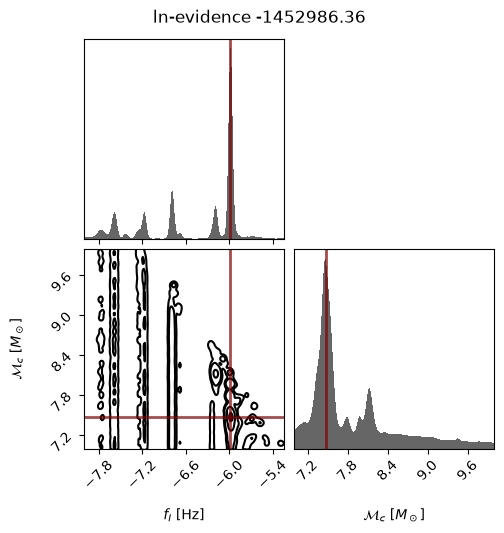

In [23]:
dynesty.plotting.cornerplot(exact_nested_samp.results, quantiles=None,
                            labels=[r'$f_I$ [Hz]', r'$\mathcal{M}_c$ [$M_\odot$]'], 
                            truths=true_mcmc_params, truth_color='maroon', 
                            smooth=0.01)
                            #span=[(-5.985, -5.97), 1])
plt.gcf().suptitle(f'ln-evidence {exact_nested_samp.results.logz[-1]:.2f}')

In [24]:
assert np.sum(~np.isfinite(exact_nested_samp.results.logl)) == 0

In [ ]:
# with ThreadPool(16) as pool:
#     roq_nested_samp = dynesty.NestedSampler(lambda th: log_prob(th, roq_wf_func), prior_transform, 2, rstate=common_random_gen_factory(),
#                                             nlive=n_live_pts, bound='multi', sample='rwalk',
#                                             live_points=draw_initial_live_pts(lambda th: log_prob(th, roq_wf_func)),
#                                             pool=pool, queue_size=16)
#     roq_nested_samp.run_nested(checkpoint_file='data/toy-mcmc/roq-wf-ns.checkpt')#, dlogz=5)

if False:
    with ThreadPool(16) as pool:
        roq_logprob = lambda th: log_prob(th, roq_wf_func)
        roq_nested_samp = nested_sampler(roq_logprob, prior_transform, 2, rstate=common_random_gen_factory(), pool=pool, live_points=draw_initial_live_pts(lambda th: log_prob(th, roq_wf_func)), **ns_init_args)
        roq_nested_samp.run_nested(checkpoint_file='data/toy-mcmc/roq-wf-ns.checkpt', **ns_run_args)#, dlogz=5)
    with open('data/toy-mcmc/roq-ns-results.pickle', 'wb') as f:
        pickle.dump(roq_nested_samp.results, f)
else:
    roq_nested_samp = dynesty.NestedSampler.restore('data/toy-mcmc/roq-wf-ns.checkpt')
    

4251it [01:38, 27.72it/s, bound: 0 | nc: 1 | ncall: 10059 | eff(%): 42.261 | loglstar:   -inf <   -inf <    inf | logz:   -inf +/-  0.018 | dlogz:  9.305 >  5.009]

In [ ]:
# dynesty.plotting.cornerplot(roq_nested_samp.results, quantiles=None,
#                             labels=[r'$f_I$ [Hz]', r'$\mathcal{M}_c$ [$M_\odot$]'], 
#                             truths=true_mcmc_params, truth_color='maroon')
#                            #span=[(-5.985, -5.97), 1])
# plt.gcf().suptitle(f'ln-evidence {roq_nested_samp.results.logz[-1]:.2f}')

In [ ]:
roq_log_l = np.array([log_prob(th, roq_wf_func) for th in tqdm.tqdm(exact_nested_samp.results.samples)])

np.save('data/toy-mcmc/roq-log-l-at-exact-samples.npy', roq_log_l)

In [ ]:
fractional_ln_L_err = np.abs((roq_log_l - exact_nested_samp.results.logl) / exact_nested_samp.results.logl)

# https://stackoverflow.com/a/54529366
def make_logscale_bins(x, bins):
  hist, bins = np.histogram(x, bins=bins)
  logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
  return logbins

logbins = make_logscale_bins(fractional_ln_L_err, 50)

l_of_split_mask = exact_nested_samp.results.samples[:, 0] < true_mcmc_params[0]
plt.hist([fractional_ln_L_err[l_of_split_mask], fractional_ln_L_err[~l_of_split_mask]], bins=logbins, stacked=True, label=['Left of ROQ partition', 'Right of ROQ partition'])
plt.legend()

plt.xscale('log')
plt.xlabel(r'$|\Delta \ln \mathcal{L} / \ln \mathcal{L}|$')
plt.ylabel('Nested sampling iteration count')